In [1]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')

<IPython.core.display.Javascript object>

## Ejercicio 7 - Péndulo invertido y equilibrio metaestable.

Sea un péndulo ideal invertido sobre un carro sobre cuyo centro de masas actúa una fuerza externa.

* El péndulo invertido está fijado en un extremo al centro de masas del carro, el cual tiene una masa $M$.     
  La rotación alrededor de este punto fijo se supone sin fricción. 


* El otro extremo del péndulo tiene una masa $m$, mientras que la varilla rígida que lo conecta con el carro tiene masa despreciable y longitud $l$.   


* El desplazamiento angular del péndulo con respecto al eje vertical se denota como $\theta$.


* El carro es capaz de moverse sólo con respecto a la superficie, es decir, sólo en la dirección $x$.   


* Sobre el péndulo sólo actúa la fuerza gravitatoria $\vec G$ en la dirección $y$ negativa.   


* Definamos las coordenadas del centro de masas del carro como $x$ e $y=0$ y las de la masa del péndulo como $x_p$ e $y_p$, que se pueden expresar en función de la posición del centro de masas del carro y el ángulo $\theta$ que forma con la vertical.


* Sobre el carro actúa la fuerza externa aplicada $\vec u$ en la dirección $x$ y la fuerza de rozamiento $\vec F$, también en la dirección x y que viene dada por $-\mu \dot x$, siendo $\dot x$ la velocidad a la que se mueve el carro y $\mu$ el coeficiente de rozamiento entre el carro y la superficie.

Las ecuaciones de movimiento del sistema vienen dadas por las ecuaciones:

\begin{align}
\ddot{x} =& \lambda(\theta)\left[m\,g\,l^2\,\dot{\theta}^2\sin\theta - m\,g\,l\,\sin\theta\,\cos\theta - l\mu \dot{x} + u\,l \right],\nonumber\\
 \ddot{\theta} =& \lambda(\theta)\left[\left(m + M\right)\,g\,\sin\theta - m\,g\,l\,\dot{\theta}^2\,\sin\theta \cos\theta +  \mu\dot{x}\cos\theta - u\cos\theta \right],\nonumber
\end{align}

siendo 

$$\lambda(\theta) = \frac{1}{l\,(M + m\sin^2\theta)}.$$

En primer lugar, vamos a estudiar la evolución del sistema partiendo de las condiciones iniciales $x(0)=\dot x(0)=\theta(0)=\dot\theta(0)=0$.


1. Usando los valores $M=1$ Kg, $m=0.1$ Kg, $l=0.2$ m, $g=9.81$ m s$^{-2}$, $\mu=10$ Kg s$^{-1}$, resolver y representar la evolución del sistema (la evolución de las coordenadas $x$ y  $\theta$) con el tiempo durante un periodo de 10 s, cuando la fuerza externa aplicada es nula, $u=0$. 

    Explicar por qué se ha elegido el método empleado para resolver el sistema de ecuaciones y el espaciado temporal que se ha usado.   
    ¿Cuál es la precisión esperada del resultado?  

    Como resultado se debería obtener que el sistema se mantiene en reposo, es decir que las condiciones iniciales representan un punto de equilibrio. 

Sin embargo, este punto de equilibrio es metaestable; cualquier perturbación del sistema hace que el péndulo caiga hacía bajo.

2. Representar la evolución del sistema en el mismo periodo del tiempo cuando la fuerza externa $\vec u$ viene descrita por un número aleatorio uniformemente distribuido con módulo máximo 0.01 Kg m s$^{-2}$ (una forma de describir, por ejemplo, el efecto del viento). 


3.  Representar también la posición en las coordenadas cartesianas del péndulo en cada instante y  el espacio de fase para las variables x y $\theta$ en todo el intervalo de tiempo ($\dot\theta$ con respecto a $\theta$, y $\dot x$ con respecto a $x$).
  
  
4. Calcular la energía cinética, potencial y total del sistema, y representar su evolución con el tiempo.  

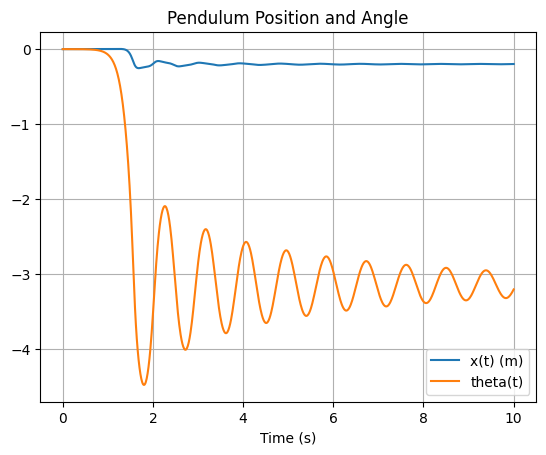

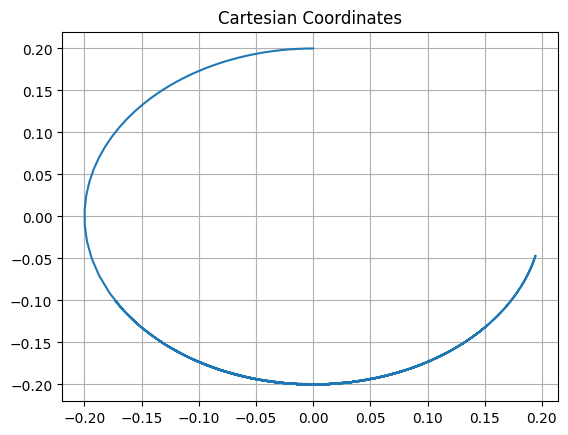

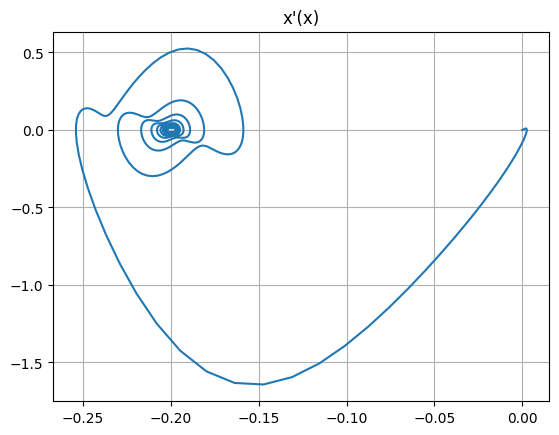

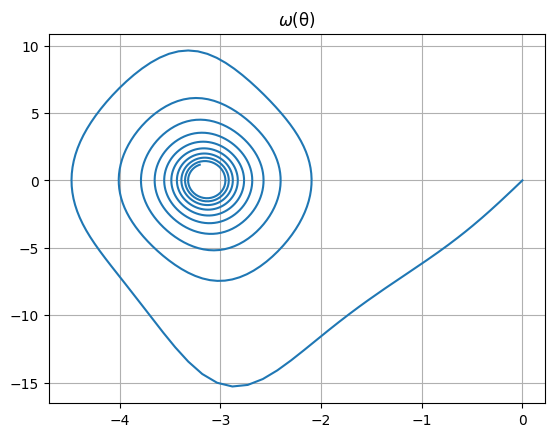

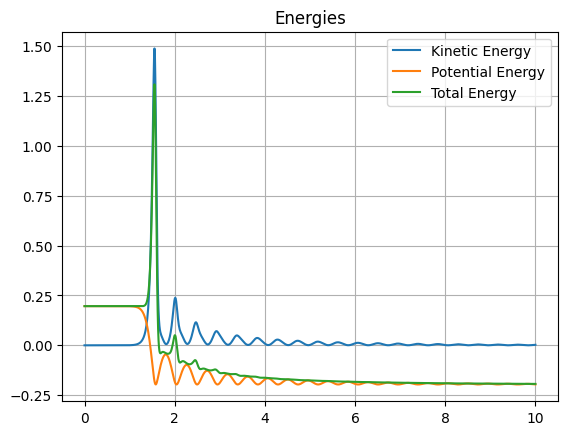

In [2]:
# Problem Constants:
M, m, l, g, mu = 1, 0.1, 0.2, 9.81, 10
u = rd.uniform(0, 0.01)
# Initial conditions:
x0, vx0, theta0, vtheta0 = 0., 0., 0., 0.
r = np.array([x0, theta0, vx0, vtheta0], float)

def F(r, t):
    # Function with the differential equations:
    x = r[0]
    theta = r[1]
    vx = r[2]
    vtheta = r[3]
    
    def lambdat(theta):
        return 1 / (l * (M + m * np.sin(theta)**2))
    
    fx = vx
    ftheta = vtheta
    fvx = lambdat(theta) * l * (m * g * np.sin(theta) * (l * vtheta**2 - np.cos(theta)) - mu * vx + u)
    fvtheta = lambdat(theta) * ((m + M) * g * np.sin(theta) - np.cos(theta) * (m * g * l * vtheta**2 * np.sin(theta) - mu * vx + u))
    return np.array([fx, ftheta, fvx, fvtheta])

def inverted_pendulum(F, a, b, N, r):
    h = (b - a) / N
    tp = np.linspace(a, b, N)
    xp = []
    thetap = []
    vxp = []
    vthetap = []
    r = np.array(r, float)
    
    # Cartesian coordinates:
    xc = []
    yc = []
    
    # Energies:
    T = []
    V = []
    E = []
    
    for t in tp:
        xp.append(r[0])
        thetap.append(r[1])
        vxp.append(r[2])
        vthetap.append(r[3])
        
        # Cartesian coordinates:
        xc.append(l * np.sin(r[1]))
        yc.append(l * np.cos(r[1]))
        
        # Energies:
        kinetic = (M * r[2]**2) / 2 + (m * (r[2]**2 + 2 * r[2] * r[3] * l * np.cos(r[1]) + (l * r[3])**2)) / 2
        pot = m * g * l * np.cos(r[1])
        T.append(kinetic)
        V.append(pot)
        E.append(kinetic + pot)
        
        k1 = h * F(r, t)
        k2 = h * F(r + k1 / 2, t + h / 2)
        k3 = h * F(r + k2 / 2, t + h / 2)
        k4 = h * F(r + k3, t + h)
        
        r += (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return tp, xp, thetap, vxp, vthetap, xc, yc, T, V, E

# Problem parameters:
t1, t2 = 0, 10
N = 1000
time, x, theta, xp, thetap, xc, yc, T, V, E = inverted_pendulum(F, t1, t2, N, r)

# Plot x(t) and theta(t):
plt.plot(time, x)
plt.plot(time, theta)
plt.xlabel("Time (s)")
plt.legend(["x(t) (m)", "theta(t)"])
plt.grid()
plt.title("Pendulum Position and Angle")
plt.show()

# Plot Cartesian coordinates:
plt.plot(xc, yc)
plt.title("Cartesian Coordinates")
plt.grid()
plt.show()

# Plot phase spaces:
plt.plot(x, xp)
plt.grid()
plt.title("x'(x)")
plt.show()
plt.plot(theta, thetap)
plt.title("$\omega$(θ)")
plt.grid()
plt.show()

# Plot energies as a function of time:
plt.plot(time, T)
plt.plot(time, V)
plt.plot(time, E)
plt.title("Energies")
plt.legend(["Kinetic Energy", "Potential Energy", "Total Energy"])
plt.grid()
plt.show()
